### Ken Vellian
#### DSC 540: Advanced Machine Learning
#### Final Project
#### Due: Nov 18, 2024 | Professor: Casey Bennett

In [1]:
#Scikit Template
'''created by Casey Bennett 2018, www.CaseyBennett.com
   Copyright 2018

   This program is free software: you can redistribute it and/or modify
   it under the terms of the GNU General Public License (Lesser GPL) as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
'''


# Import necessary libraries
import pandas as pd
import numpy as np
import time
import warnings
import sys
import csv
import math
import copy
import random
from operator import itemgetter
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import RocCurveDisplay
from sklearn.exceptions import NotFittedError

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.feature_selection import RFE, VarianceThreshold, SelectFromModel
from sklearn.feature_selection import SelectKBest, mutual_info_regression, mutual_info_classif, chi2
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, scale
from sklearn import metrics
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV



# from sklearn.externals import joblib


# Suppress warnings
warnings.filterwarnings("ignore", category=Warning)

# Adjust pandas display settings to maximize columns and widths
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

## Load Data

In [2]:
#############################################################################
#
# Load Data
#
#############################################################################

# Load dataset into a Pandas DataFrame
file_path = 'hospital_readmissions.csv'
df = pd.read_csv(file_path)

# # Making a subset to test code before running on full data set for runtime purposes
# df = df.head(1000)

df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [3]:
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [5]:
df.count().isna()

age                  False
time_in_hospital     False
n_lab_procedures     False
n_procedures         False
n_medications        False
n_outpatient         False
n_inpatient          False
n_emergency          False
medical_specialty    False
diag_1               False
diag_2               False
diag_3               False
glucose_test         False
A1Ctest              False
change               False
diabetes_med         False
readmitted           False
dtype: bool

In [6]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Get unique values for categorical columns
categorical_unique_values = {col: df[col].unique().tolist() for col in categorical_columns}

# Convert unique values and numerical summary to DataFrames
categorical_df = pd.DataFrame([(col, values) for col, values in categorical_unique_values.items()],
                              columns=['Categorical Column', 'Unique Values'])

In [7]:
categorical_df

,Categorical Column,Unique Values
0,age,"[[70-80), [50-60), [60-70), [40-50), [80-90), [90-100)]"
1,medical_specialty,"[Missing, Other, InternalMedicine, Family/GeneralPractice, Cardiology, Surgery, Emergency/Trauma]"
2,diag_1,"[Circulatory, Other, Injury, Digestive, Respiratory, Diabetes, Musculoskeletal, Missing]"
3,diag_2,"[Respiratory, Other, Circulatory, Injury, Diabetes, Digestive, Musculoskeletal, Missing]"
4,diag_3,"[Other, Circulatory, Diabetes, Respiratory, Injury, Musculoskeletal, Digestive, Missing]"
5,glucose_test,"[no, normal, high]"
6,A1Ctest,"[no, normal, high]"
7,change,"[no, yes]"
8,diabetes_med,"[yes, no]"
9,readmitted,"[no, yes]"


In [8]:
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


## Data Preprocessing:

### Converting the categorical values into decending numbers based on alphabetical order. 

### One hot encoding would increase the dimensionality of the dataset and affect feature selection. 
### This approach should work for our ensemble model. However, this approach would not work well if we were using distance based models like SVM or LR.

### Creating a map for all unique categorical values to convert the dataframe.

In [9]:
# Define mappings for categorical variables

age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45, 
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}

medical_specialty_map = {
    'Missing': 0, 'Cardiology': 1, 'Emergency/Trauma': 2, 'Family/GeneralPractice': 3, 
    'InternalMedicine': 4, 'Other': 5, 'Surgery': 6
}

diagnosis_map = {
    'Missing': 0, 'Circulatory': 1, 'Diabetes': 2, 'Digestive': 3, 'Injury': 4, 
    'Musculoskeletal': 5, 'Other': 6, 'Respiratory': 7
}

glucose_test_map = {
    'no': 0, 'normal': 1, 'high': 2
}

A1Ctest_map = {
    'no': 0, 'normal': 1, 'high': 2
}

change_map = {
    'no': 0, 'yes': 1
}

diabetes_med_map = {
    'no': 0, 'yes': 1
}

readmitted_map = {
    'no': 0, 'yes': 1
}

In [10]:
# Apply the mappings to the categorical variables
df['age'] = df['age'].map(age_map)
df['medical_specialty'] = df['medical_specialty'].map(medical_specialty_map)
df['diag_1'] = df['diag_1'].map(diagnosis_map)
df['diag_2'] = df['diag_2'].map(diagnosis_map)
df['diag_3'] = df['diag_3'].map(diagnosis_map)
df['glucose_test'] = df['glucose_test'].map(glucose_test_map)
df['A1Ctest'] = df['A1Ctest'].map(A1Ctest_map)
df['change'] = df['change'].map(change_map)
df['diabetes_med'] = df['diabetes_med'].map(diabetes_med_map)
df['readmitted'] = df['readmitted'].map(readmitted_map)

In [11]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,75,8,72,1,18,2,0,0,0,1,7,6,0,0,0,1,0
1,75,3,34,2,13,0,0,0,5,6,6,6,0,0,0,1,0
2,55,5,45,0,18,0,0,0,0,1,1,1,0,0,1,1,1
3,75,2,36,0,12,1,0,0,0,1,6,2,0,0,1,1,1
4,65,1,42,0,7,0,0,0,4,6,1,7,0,0,0,1,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                25000 non-null  int64
 1   time_in_hospital   25000 non-null  int64
 2   n_lab_procedures   25000 non-null  int64
 3   n_procedures       25000 non-null  int64
 4   n_medications      25000 non-null  int64
 5   n_outpatient       25000 non-null  int64
 6   n_inpatient        25000 non-null  int64
 7   n_emergency        25000 non-null  int64
 8   medical_specialty  25000 non-null  int64
 9   diag_1             25000 non-null  int64
 10  diag_2             25000 non-null  int64
 11  diag_3             25000 non-null  int64
 12  glucose_test       25000 non-null  int64
 13  A1Ctest            25000 non-null  int64
 14  change             25000 non-null  int64
 15  diabetes_med       25000 non-null  int64
 16  readmitted         25000 non-null  int64
dtypes: int64(17)

### Our target variable to classify is "readmitted".
### In this step, the dataframe into separate "target" and "data" dataframes.
### Dropping the target variable from the "data".

In [13]:
# Separate the target and features

target = df['readmitted']
data = df.drop(columns=['readmitted'])

# Update header to exclude 'readmitted'
header = list(data.columns)



In [14]:
# Check the first few rows of data and target
data.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med
0,75,8,72,1,18,2,0,0,0,1,7,6,0,0,0,1
1,75,3,34,2,13,0,0,0,5,6,6,6,0,0,0,1
2,55,5,45,0,18,0,0,0,0,1,1,1,0,0,1,1
3,75,2,36,0,12,1,0,0,0,1,6,2,0,0,1,1
4,65,1,42,0,7,0,0,0,4,6,1,7,0,0,0,1


In [15]:
# Check info of data to confirm types and mappings
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                25000 non-null  int64
 1   time_in_hospital   25000 non-null  int64
 2   n_lab_procedures   25000 non-null  int64
 3   n_procedures       25000 non-null  int64
 4   n_medications      25000 non-null  int64
 5   n_outpatient       25000 non-null  int64
 6   n_inpatient        25000 non-null  int64
 7   n_emergency        25000 non-null  int64
 8   medical_specialty  25000 non-null  int64
 9   diag_1             25000 non-null  int64
 10  diag_2             25000 non-null  int64
 11  diag_3             25000 non-null  int64
 12  glucose_test       25000 non-null  int64
 13  A1Ctest            25000 non-null  int64
 14  change             25000 non-null  int64
 15  diabetes_med       25000 non-null  int64
dtypes: int64(16)
memory usage: 3.1 MB


In [16]:
target.head()

0    0
1    0
2    1
3    1
4    0
Name: readmitted, dtype: int64

In [17]:
target.info()

<class 'pandas.core.series.Series'>
RangeIndex: 25000 entries, 0 to 24999
Series name: readmitted
Non-Null Count  Dtype
--------------  -----
25000 non-null  int64
dtypes: int64(1)
memory usage: 195.4 KB


# Converting dataframes to numpy arrays

In [18]:
# Convert data and target to numpy arrays for further processing
data_np = data.to_numpy()
target_np = target.to_numpy()

# Confirm preprocessing steps
print("Data Shape:", data_np.shape)
print("Target Shape:", target_np.shape)

Data Shape: (25000, 16)
Target Shape: (25000,)


In [19]:
print(header)

['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']


# Defining Global Variables

In [20]:
#############################################################################
#
# Global Parameters
#
#############################################################################

lv_filter= 0                                        #Control switch for low variance filter on features
lasso_reg = 1                                       #Set to 1 to apply Lasso regularization, 0 to skip it.
vif_filter= 0

feat_select= 0                                       #Control Switch for Feature Selection      
fs_type= 1                                           #Feature Selection type (1=Stepwise Backwards Removal, 2=Wrapper Select, 3=Univariate Selection)

hyperparameter_tuning = 0                           # Set to 1 to enable, 0 to skip
tuning_type = "random"                              # Options: 'grid' or 'random'

cross_val=1                                         #Control Switch for CV  


norm_target=0                                       #Normalize target switch
norm_features=0                                     #Normalize features switch
k_cnt=5                                             #Number of 'Top k' best ranked features to select, only applies for fs_types 1 and 3
binning=1                                           #Control Switch for Bin Target
bin_cnt=2                                           #If bin target, this sets number of classes

#Set global model parameters
rand_st=1                                           #Set Random State variable for randomizing splits on runs


# Data Transformation: Data Preprocessing 

In [21]:
# Step 3a: Target normalization if specified
if norm_target == 1:
    # Target normalization for continuous values
    target_np = scale(target_np)

# Step 3b: Feature normalization if specified
if norm_features == 1:
    # Feature normalization for continuous values
    data_np = scale(data_np)
    
# Confirm preprocessing steps
print("Data Shape:", data_np.shape)
print("Target Shape:", target_np.shape)
print("First 5 Rows of Data:\n", data_np[:5])
print("First 5 Target Values:", target_np[:5])

Data Shape: (25000, 16)
Target Shape: (25000,)
First 5 Rows of Data:
 [[75  8 72  1 18  2  0  0  0  1  7  6  0  0  0  1]
 [75  3 34  2 13  0  0  0  5  6  6  6  0  0  0  1]
 [55  5 45  0 18  0  0  0  0  1  1  1  0  0  1  1]
 [75  2 36  0 12  1  0  0  0  1  6  2  0  0  1  1]
 [65  1 42  0  7  0  0  0  4  6  1  7  0  0  0  1]]
First 5 Target Values: [0 0 1 1 0]


# Feature Selection

Length of header: 16
Number of columns in data_np: 16


--LOW VARIANCE FILTER OFF-- 


--LASSO REGULARIZATION ON-- 


Feature Coefficients (sorted by absolute value):
n_inpatient: 0.0758
n_outpatient: 0.0202
n_emergency: 0.0160
n_procedures: -0.0085
medical_specialty: -0.0078
diabetes_med: 0.0059
diag_1: -0.0042
time_in_hospital: 0.0024
n_medications: 0.0013
age: 0.0011
diag_2: -0.0005
n_lab_procedures: 0.0003
diag_3: -0.0000
glucose_test: 0.0000
A1Ctest: -0.0000
change: 0.0000

Selected Features after Lasso Regularization: ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diabetes_med']
Removed Features due to Lasso Regularization: ['diag_3', 'glucose_test', 'A1Ctest', 'change']
Features (total, selected): 16 12 

Lasso Regularization Runtime: 0.02 seconds

--VIF FILTER OFF-- 

--FEATURE SELECTION OFF-- 


--ML Model Output-- 


--Feature and Data Check Before Model T

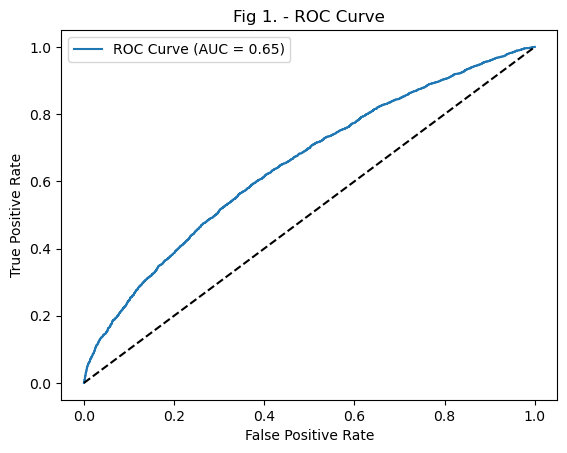

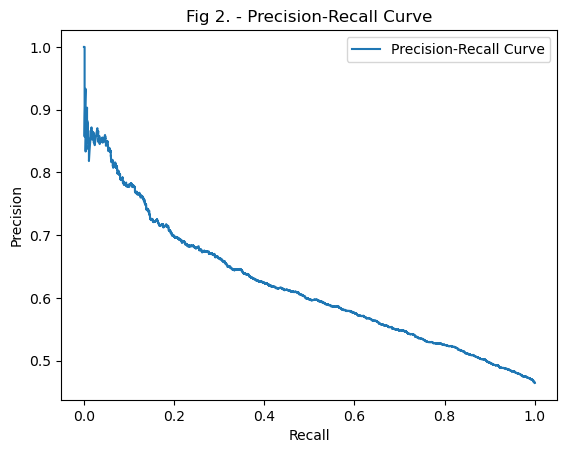


Model Evaluation Summary:
Accuracy:
0.6126857142857143
Confusion_matrix:
[[3406 1278]
 [2111 1955]]
Classification_report:

              precision    recall  f1-score   support

     Class 0       0.62      0.73      0.67      4684
     Class 1       0.60      0.48      0.54      4066

    accuracy                           0.61      8750
   macro avg       0.61      0.60      0.60      8750
weighted avg       0.61      0.61      0.61      8750

Roc_auc:
0.6489753503570254


In [22]:
#############################################################################
#
# Feature Selection
#
##########################################

print("Length of header:", len(header)) 
print("Number of columns in data_np:", data_np.shape[1])  # Should match len(header)

# Low Variance Filter
if lv_filter == 1:
    print('\n\n--LOW VARIANCE FILTER ON--', '\n')

    start_time = time.time()  # Start timer for Low Variance Filter
    sel = VarianceThreshold(threshold=0.5)
    fit_mod = sel.fit(data_np)
    sel_idx = fit_mod.get_support()

    # Adjust selected and removed features
    selected_features = [header[i] for i in range(len(sel_idx)) if sel_idx[i]]
    removed_features = [header[i] for i in range(len(sel_idx)) if not sel_idx[i]]
    
    # Print selected and removed features
    print('Selected Features:', selected_features)
    print('Removed Features:', removed_features)
    print('Features (total, selected):', len(header), len(selected_features))
    print('\n')

    # Filter the original dataset and adjust `header` to reflect only selected features
    header = selected_features  # Update header with only selected feature names
    data_np = data_np[:, sel_idx]  # Keeps only columns where sel_idx is True
    print(f"Low Variance Filter Runtime: {time.time() - start_time:.2f} seconds\n")

else:
    print('\n\n--LOW VARIANCE FILTER OFF--', '\n')


# Lasso Regularization
if lasso_reg == 1:
    print("\n--LASSO REGULARIZATION ON--", '\n')

    start_time = time.time()  # Start timer for Lasso
    from sklearn.linear_model import Lasso
    lasso = Lasso(alpha=0.01, random_state=rand_st)  # Adjust alpha based on data
    lasso.fit(data_np, target_np)

    # Extract coefficients
    lasso_coefs = lasso.coef_

    # Map coefficients to feature names
    feature_coef_map = list(zip(header, lasso_coefs))
    feature_coef_map.sort(key=lambda x: abs(x[1]), reverse=True)  # Sort by magnitude

    # Print all coefficients
    print("\nFeature Coefficients (sorted by absolute value):")
    for feature, coef in feature_coef_map:
        print(f"{feature}: {coef:.4f}")

    # Extract non-zero coefficients (selected features)
    selected_features_idx = [i for i, coef in enumerate(lasso_coefs) if coef != 0]
    selected_features = [header[i] for i in selected_features_idx]
    removed_features = [header[i] for i in range(len(header)) if i not in selected_features_idx]

    # Print results
    print("\nSelected Features after Lasso Regularization:", selected_features)
    print("Removed Features due to Lasso Regularization:", removed_features)
    print("Features (total, selected):", len(header), len(selected_features), '\n')

    # Update header and data_np
    header = selected_features
    data_np = data_np[:, selected_features_idx]
    print(f"Lasso Regularization Runtime: {time.time() - start_time:.2f} seconds\n")

else:
    print("\n--LASSO REGULARIZATION OFF--", '\n')



# VIF Filter
if vif_filter == 1:
    
    print("\n--VIF FILTER ON--")

    print("Variance Inflation Factor (VIF) scores for all features before VIF Filter:")
    
    vif_threshold = 5  # Adjust as needed
    start_time = time.time()  # Start timer for VIF Filter

    # Calculate VIF scores
    vif_data = pd.DataFrame()
    vif_data["feature"] = header  # Use updated header
    vif_data["VIF"] = [variance_inflation_factor(data_np, i) for i in range(data_np.shape[1])]

    # Display VIF scores for all features
    for feature, vif in zip(vif_data["feature"], vif_data["VIF"]):
        print(f"{feature}: VIF = {vif:.2f}")

    # Separate selected and removed features based on VIF threshold
    selected_features = []
    removed_features = []
    temp_del = []

    for i in range(len(vif_data)):
        feature = vif_data["feature"][i]
        vif = vif_data["VIF"][i]

        if vif <= vif_threshold:
            selected_features.append(feature)
        else:
            removed_features.append(feature)
            temp_del.append(i)

    print("Selected Features after VIF Filter:", selected_features)
    print("Removed Features due to high VIF:", removed_features)
    print("Features (total, selected):", len(header), len(selected_features))
    print("\n")

    # Update header and filter data_np by removing columns with high VIF
    header = selected_features  # Replace header with selected features
    data_np = np.delete(data_np, temp_del, axis=1)  # Remove columns where VIF > threshold

    # Final VIF scores for selected features
    print("Variance Inflation Factor (VIF) scores for selected features after VIF Filter:")
    vif_scores_selected = [variance_inflation_factor(data_np, i) for i in range(data_np.shape[1])]
    for feature, vif in zip(selected_features, vif_scores_selected):
        print(f"{feature}: VIF = {vif:.2f}")
    print(f"VIF Filter Runtime: {time.time() - start_time:.2f} seconds\n")

else:
    print("--VIF FILTER OFF--", "\n")



# Feature Selection
if feat_select == 1:
    '''Three steps:
       1) Run Feature Selection
       2) Get lists of selected and non-selected features
       3) Filter columns from the original dataset
    '''
    
    print('--FEATURE SELECTION ON--', '\n')
    start_time = time.time()  # Start timer for Feature Selection

    ## 1) Run Feature Selection #######
    if fs_type == 1:
        # Stepwise Recursive Backwards Feature removal using Random Forest
        
        clf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=3, criterion='entropy', random_state=rand_st)
        print('Stepwise Recursive Backwards - Random Forest:')
        

        sel = RFE(clf, n_features_to_select=k_cnt, step=0.1)  # Recursive Feature Elimination

        # Fit the model and get feature rankings
        fit_mod = sel.fit(data_np, target_np)
        sel_idx = fit_mod.get_support()  # Boolean mask of selected features
        ranking = sel.ranking_  # Feature rankings
        
        # Display rankings and selected features
        print('Feature Ranking:', ranking)
        selected_features = [header[i] for i in range(len(sel_idx)) if sel_idx[i]]
        removed_features = [header[i] for i in range(len(sel_idx)) if not sel_idx[i]]
        
        print('Selected Features:', selected_features)
        print('Removed Features:', removed_features)
        print('Features (total, selected):', len(header), len(selected_features), '\n')

    elif fs_type == 2:
        # Wrapper Select using Random Forest
        
        clf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=3, criterion='entropy', random_state=rand_st)
        print('Wrapper Select - Random Forest:')
        
        
        sel = SelectFromModel(clf, prefit=False, threshold='mean', max_features=None)  # Feature selection
        
        
        # Fit the model and get selected features
        fit_mod = sel.fit(data_np, target_np)
        sel_idx = fit_mod.get_support()  # Boolean mask of selected features
        
        # Display selected features
        selected_features = [header[i] for i in range(len(sel_idx)) if sel_idx[i]]
        removed_features = [header[i] for i in range(len(sel_idx)) if not sel_idx[i]]
        
        print('Selected Features:', selected_features)
        print('Removed Features:', removed_features)
        print('Features (total, selected):', len(header), len(selected_features), '\n')

    elif fs_type == 3:
        # Univariate Feature Selection - Chi-squared
        sel = SelectKBest(chi2, k=k_cnt)
        fit_mod = sel.fit(data_np, target_np)  # Fit the Chi-squared test
        sel_idx = fit_mod.get_support()  # Boolean mask of selected features
        
        # Print ranked variables sorted by score
        scores = fit_mod.scores_
        ranked_features = sorted(
            [(header[i], scores[i]) for i in range(len(scores))], 
            key=lambda x: x[1], 
            reverse=True
        )
        
        print('Univariate Feature Selection - Chi2 Ranked Features:')
        for idx, (feature, score) in enumerate(ranked_features):
            print(f"{idx + 1}. {feature}: {score:.2f}")
        
        # Filter selected and removed features
        selected_features = [header[i] for i in range(len(sel_idx)) if sel_idx[i]]
        removed_features = [header[i] for i in range(len(sel_idx)) if not sel_idx[i]]
        
        print('Selected Features:', selected_features)
        print('Removed Features:', removed_features)
        print('Features (total, selected):', len(header), len(selected_features), '\n')    

    ## 2) Filter columns from the original dataset #######
    temp_idx = [i for i in range(len(sel_idx)) if sel_idx[i]]
    temp_del = [i for i in range(len(sel_idx)) if not sel_idx[i]]
    
    # Update `header` and `data_np` to retain only selected features
    header = [header[i] for i in temp_idx]
    data_np = data_np[:, temp_idx]

    # Confirm alignment of header and data_np
    print('Final Selected Features:', header)
    print('Features (total, selected):', len(sel_idx), len(header))
    print('Filtered dataset shape:', data_np.shape, '\n')
    print(f"Feature Selection Runtime: {time.time() - start_time:.2f} seconds\n")
    
else:
    print('--FEATURE SELECTION OFF--', '\n')

#############################################################################
#
# Train SciKit Models
#
##########################################

print('\n--ML Model Output--', '\n')

# Print selected feature names and dataset details for verification
print("\n--Feature and Data Check Before Model Training--")
print("Selected Features (header):", header)
print("Shape of data_np (Selected Features):", data_np.shape)
print("Shape of target_np:", target_np.shape)

# Test/Train split
data_train, data_test, target_train, target_test = train_test_split(data_np, target_np, test_size=0.35)

# Hyperparameter Tuning (Grid Search or Random Search)
if hyperparameter_tuning == 1:
    print("\n--Hyperparameter Tuning ON--")
    start_ts = time.time()

    # Gridsearch was too computationally expensive. Using random search until we find consistent parameters.
    if tuning_type == "grid":

        # param_dist 1: Result for this grid below
        # Used for the 15 experiments
        # param_grid = {
        #     'n_estimators': [100, 200, 500],
        #     'max_depth': [None, 10, 20],
        #     'min_samples_split': [2, 5, 10],
        #     'criterion': ['gini', 'entropy']
        # }

        # It appears we might be hitting the practical limit for the Random Forest Classifier with this dataset
        # param_dist 5: Tweaking for best results from Excel row 22 (just lasso regression)
        # Last test to see if we can make any more improvements.... 
        # Using param_dist 5 on GridsearchCV
        param_grid = {
            'n_estimators': [400, 500, 600],      # Focus around the best value (500)
            'max_depth': [7, 8, 9],               # Narrow around the best depth (8)
            'min_samples_split': [6, 8, 10],      # Fine-tune split thresholds
            'min_samples_leaf': [1, 2],           # Test slight variations in leaf count
            'max_features': ['sqrt', 'log2'],     # Focus on top-performing options
            'criterion': ['gini'],                # Stick to the best-observed criterion
            'bootstrap': [True]                   # Use the consistently better-performing bootstrap
        }
        
        grid_search = GridSearchCV(
            estimator=RandomForestClassifier(random_state=rand_st),
            param_grid=param_grid,
            scoring='roc_auc',  # Change to 'accuracy' for multi-class problems
            cv=5,
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(data_train, target_train)
        print("Best Parameters (Grid Search):", grid_search.best_params_)
        clf = grid_search.best_estimator_

    elif tuning_type == "random":
        # # # Used for the 15 experiments
        # # # Results from row 6: clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, criterion='entropy', random_state=rand_st)
        # param_dist = {
        #     'n_estimators': [100, 200, 500],
        #     'max_depth': [None, 10, 20],
        #     'min_samples_split': [2, 5, 10],
        #     'criterion': ['gini', 'entropy']
        # }

        # # param_dist 2: Tweaking for best results from Excel row 6 (just lasso regression) 
        # # Results from param_dist 2 building from row 6 on Excel row 21
        # # BEST RESULTS
        # # clf = RandomForestClassifier(n_estimators=500, min_samples_split=8, min_samples_leaf=1, max_features='sqrt', max_depth=8, criterion='gini', random_state=rand_st)
        # # Fine-tuning further to see if we can improve the results.
        # param_dist = {
        #     'n_estimators': [400, 500, 600],  # Incrementally test around the best value
        #     'max_depth': [8, 10, 12],         # Explore values close to 10
        #     'min_samples_split': [8, 10, 12], # Narrow range around 10
        #     'criterion': ['gini', 'entropy'], # Retain both options for exploration
        #     'min_samples_leaf': [1, 2, 4],    # Include to control leaf size
        #     'max_features': ['sqrt', 'log2', None] # Explore feature subset size
        # }

        # param_dist 3: Tweaking for best results from Excel row 21 (just lasso regression)
        # Results from param_dist 3 building from row 21 on Excel row 22
        # clf = RandomForestClassifier(n_estimators=800, min_samples_split=10, min_samples_leaf=1, max_features='log2', max_depth=9, criterion='gini', bootstrap=True, random_state=rand_st)
        # Fine-tuning further to see if we can improve the results.
        # param_dist = {
        #     'n_estimators': [500, 600, 700, 800],  # Test stability with more trees
        #     'max_depth': [7, 8, 9, 10],  # Narrow around 8 for refinement
        #     'min_samples_split': [6, 8, 10],  # Fine-tune split thresholds
        #     'min_samples_leaf': [1, 2, 3],  # Explore slightly higher leaf counts
        #     'max_features': ['sqrt', 'log2', None],  # Test diversity in feature selection
        #     'criterion': ['gini', 'entropy'],  # Keep both options for splitting
        #     'bootstrap': [True, False]  # Introduce bootstrap testing
        # }

        # Given the results above, let's fine-tune further until we plateau.
        # param_dist 4: Tweaking for best results from Excel row 22 (just lasso regression)
        # clf = RandomForestClassifier(n_estimators=600, min_samples_split=10, min_samples_leaf=2, max_features='log2', max_depth=9, criterion='gini', bootstrap=True, random_state=rand_st)
        # param_dist = {
        #     'n_estimators': [600, 700, 800],  # Fine-tune around 800
        #     'max_depth': [8, 9, 10],          # Focus on best-performing depths
        #     'min_samples_split': [8, 9, 10],  # Fine-tune split thresholds
        #     'min_samples_leaf': [1, 2],       # Test slight variations in leaf count
        #     'max_features': ['log2', 'sqrt'], # Stick to most promising options
        #     'criterion': ['gini'],            # Limit to best-observed criterion
        #     'bootstrap': [True, False]        # Retain bootstrap for simplicity
        # }

        # It appears we might be hitting the practical limit for the model and dataset
        # param_dist 5: Tweaking for best results from Excel row 22 (just lasso regression)
        # Last test to see if we can make any more improvements.... 
        # Using param_dist 5 on GridsearchCV
        param_dist = {
            'n_estimators': [400, 500, 600],      # Focus around the best value (500)
            'max_depth': [7, 8, 9],               # Narrow around the best depth (8)
            'min_samples_split': [6, 8, 10],      # Fine-tune split thresholds
            'min_samples_leaf': [1, 2],           # Test slight variations in leaf count
            'max_features': ['sqrt', 'log2'],     # Focus on top-performing options
            'criterion': ['gini'],                # Stick to the best observed criterion
            'bootstrap': [True]                   # Use the consistently better-performing bootstrap
        }


        random_search = RandomizedSearchCV(
            estimator=RandomForestClassifier(random_state=rand_st),
            param_distributions=param_dist,
            scoring='roc_auc',
            n_iter=20,
            cv=5,
            n_jobs=-1,
            verbose=1
        )
        random_search.fit(data_train, target_train)
        print("Best Parameters (Random Search):", random_search.best_params_)
        clf = random_search.best_estimator_
    print("Hyperparameter Tuning Runtime:", time.time() - start_ts)
    print("--Hyperparameter Tuning Completed--\n")
    
else:
    print("\n--Hyperparameter Tuning OFF--")


#### Classifiers ####
if binning == 1 and cross_val == 0:
    print('--CROSS VALIDATION OFF--', '\n')
    
    # Random Forest Classifier
    start_ts = time.time()
    clf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=3, criterion='entropy', random_state=rand_st)
    clf.fit(data_train, target_train)
    print('\nRandom Forest Acc:', clf.score(data_test, target_test))
    if bin_cnt <= 2:
        print('Random Forest AUC:', metrics.roc_auc_score(target_test, clf.predict_proba(data_test)[:, 1]))
    print("Runtime:", time.time() - start_ts)

#### Cross-Val Classifiers ####
if binning == 1 and cross_val == 1:
    print('\n\n--CROSS VALIDATION ON--', '\n')

    # Setup Cross-Val classifier scorers
    if bin_cnt <= 2:
        scorers = {'Accuracy': 'accuracy', 'roc_auc': 'roc_auc'}
    else:
        scorers = {'Accuracy': 'accuracy'}
    
    # Random Forest Classifier - Cross Val
    start_ts = time.time()
    # # original clf
    # # Global variables used: lv_filter == 0, lasso_reg == 0, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 0, tuning_type == 'grid'
    # clf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=3, criterion='gini', random_state=rand_st)

    #  ROW 3 and 4 in EXCEL: param_grid 1 results (same for grid and random)
    # Global variables used: lv_filter == 0, lasso_reg == 0, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random','grid'# #
    # clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, criterion='gini', random_state=rand_st)

    #  ROW 5 in EXCEL: param_dist 1 results (using random)
    # # Global variables used: lv_filter == 1, lasso_reg == 0, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, criterion='gini', random_state=rand_st)
    
    # # ROW 6 in EXCEL: param_dist 1 results (using random)  
    # # Global variables used: lv_filter == 0, lasso_reg == 1, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, criterion='entropy', random_state=rand_st)

    # # ROW 7 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 0, lasso_reg == 0, vif_filter == 1, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, criterion='entropy', random_state=rand_st)

    # # ROW 8 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 0, lasso_reg == 0, vif_filter == 0, feat_select == 1, fs_type == 1, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, criterion='gini', random_state=rand_st)

    # # ROW 9 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 0, lasso_reg == 0, vif_filter == 0, feat_select == 1, fs_type == 2, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, criterion='gini', random_state=rand_st)

    # # ROW 10 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 0, lasso_reg == 0, vif_filter == 0, feat_select == 1, fs_type == 3, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, criterion='entropy', random_state=rand_st)

    # # ROW 11 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 1, lasso_reg == 1, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=5, criterion='entropy', random_state=rand_st)

    # # ROW 12 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 1, lasso_reg == 1, vif_filter == 1, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, criterion='entropy', random_state=rand_st)
    

    # # ROW 13 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 1, lasso_reg == 1, vif_filter == 1, feat_select == 1, fs_type == 1, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, criterion='gini', random_state=rand_st)

    # # ROW 14 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 1, lasso_reg == 1, vif_filter == 1, feat_select == 1, fs_type == 2, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, criterion='entropy', random_state=rand_st)

    # # ROW 15 in EXCEL: param_dist 1 results (using random) # 
    # # Global variables used: lv_filter == 1, lasso_reg == 1, vif_filter == 1, feat_select == 1, fs_type == 3, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, criterion='entropy', random_state=rand_st)


    # BEST RESULTS FROM ROW 6: Adjusting hyperparameter lists to fine-tune our model

    
    # ROW 16 is the OVERALL BEST RESULT *********
    
    # ROW 16 in EXCEL: ROW 6 with Lasso Regression the best result. Using param_dist 2 to fine-tune hyperparameters, now on Excel ROW 16
    # # Global variables used: lv_filter == 0, lasso_reg == 1, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    clf = RandomForestClassifier(n_estimators=500, min_samples_split=8, min_samples_leaf=1, max_features='sqrt', max_depth=8, criterion='gini', random_state=rand_st)

    
    # ROW 17 in EXCEL: Using param_dist 3 to fine-tune hyperparameters, now on Excel ROW 17
    # # Global variables used: lv_filter == 0, lasso_reg == 1, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=800, min_samples_split=10, min_samples_leaf=1, max_features='log2', max_depth=9, criterion='gini', bootstrap=True, random_state=rand_st)# 

    # # ROW 18 in EXCEL: Using param_dist 4 to fine-tune hyperparameters, now on Excel ROW 18
    # # Global variables used: lv_filter == 0, lasso_reg == 1, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'random'
    # clf = RandomForestClassifier(n_estimators=600, min_samples_split=10, min_samples_leaf=2, max_features='log2', max_depth=9, criterion='gini', bootstrap=True, random_state=rand_st)


    # # ATTEMPTING GRIDSEARCH with more parameters. Extremely computationally expensive.
    # # ROW 19 in EXCEL: Used gridsearchCV on param_grid 5 for the parameters below
    # # Global variables used: lv_filter == 0, lasso_reg == 1, vif_filter == 0, feat_select == 0, fs_type == 0, cross_val == 1, hyperparameter_tuning == 1, tuning_type == 'grid'
    # clf = RandomForestClassifier(n_estimators=500, min_samples_split=6, min_samples_leaf=2, max_features='sqrt', max_depth=9, criterion='gini', bootstrap=True, random_state=rand_st)

    
    scores = cross_validate(clf, data_np, target_np, scoring=scorers, cv=5)
    scores_Acc = scores['test_Accuracy']
    print("\nRandom Forest Acc: %0.2f (+/- %0.2f)" % (scores_Acc.mean(), scores_Acc.std() * 2))
    if bin_cnt <= 2:
        scores_AUC = scores['test_roc_auc']
        print("Random Forest AUC: %0.2f (+/- %0.2f)" % (scores_AUC.mean(), scores_AUC.std() * 2))
    print("CV Runtime:", time.time() - start_ts)


#############################################################################
#
# Train the Model
#
#############################################################################
print("\n--TRAINING THE MODEL--\n")
random.seed(123)

# Fit the model
clf.fit(data_train, target_train)
print("Model trained successfully.")


#############################################################################
#
# Model Evaluation
#
#############################################################################


print("\n\n--MODEL EVALUATION--\n")

# Ensure the model is fitted
try:
    # Predictions
    predictions = clf.predict(data_test)
    proba_predictions = clf.predict_proba(data_test)[:, 1] if hasattr(clf, 'predict_proba') else None

    # Accuracy
    accuracy = accuracy_score(target_test, predictions)
    print(f"Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    conf_matrix = confusion_matrix(target_test, predictions)
    print("\nConfusion Matrix:")
    print(conf_matrix)

    # Classification Report
    class_report = classification_report(target_test, predictions, target_names=['Class 0', 'Class 1'])
    print("\nClassification Report:")
    print(class_report)

    # ROC-AUC Score (for binary classification only)
    if len(set(target_test)) == 2 and proba_predictions is not None:
        auc_score = roc_auc_score(target_test, proba_predictions)
        print(f"\nROC-AUC Score: {auc_score:.4f}")
        
        # Plotting the ROC Curve
        fpr, tpr, thresholds = roc_curve(target_test, proba_predictions)
        plt.figure()
        plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Fig 1. - ROC Curve")
        plt.legend()
        plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Precision-Recall Curve
    if proba_predictions is not None:
        precision, recall, pr_thresholds = precision_recall_curve(target_test, proba_predictions)
        plt.figure()
        plt.plot(recall, precision, label="Precision-Recall Curve")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Fig 2. - Precision-Recall Curve")
        plt.legend()
        plt.savefig('precision_recall.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Save evaluation results to a dictionary
    evaluation_results = {
        "accuracy": accuracy,
        "confusion_matrix": conf_matrix,
        "classification_report": class_report,
    }
    if len(set(target_test)) == 2 and proba_predictions is not None:
        evaluation_results["roc_auc"] = auc_score

    # Print summary of evaluation
    print("\nModel Evaluation Summary:")
    for key, value in evaluation_results.items():
        print(f"{key.capitalize()}:")
        print(value if not isinstance(value, str) else "\n" + value)

except NotFittedError as e:
    print("\nError: Model is not fitted.")
    print(e)

